# Customer Churn Prediction using Artificial Neural Networks (ANN)
### Author - Sanyukta Saha, MSc Statistics and Computing (BHU)

## Introduction

Customer churn is when a customer stops using a company's products or services. In subscription-driven industries such as banking, telecom and SaaS, churn directly reduces revenue. Acquiring a new customer is also usually far more expensive than retaining an existing one. Identifying customers who are likely to leave, before they do, lets a business act early with targeted retention offers and better service.

This project builds a deep learning model, an **Artificial Neural Network (ANN)**, to predict whether a customer will churn based on demographic, account and behavioural features. ANNs suit this task because they can learn complex, non-linear relationships between features that simpler models may miss.

**Dataset:** [dataset name/source], with [number] customer records and [number] features, including [e.g., credit score, geography, age, tenure, balance, number of products, active membership status, estimated salary]. The target variable is `Exited` / `Churn` (1 = churned, 0 = retained).


## Objectives

The primary objective of this project is to develop a machine learning-based framework for predicting customer churn and identifying the factors that contribute to customer attrition.

Specific objectives include:

1. To perform exploratory data analysis (EDA) and understand customer behavior patterns.
2. To preprocess and clean the dataset by handling missing values, encoding categorical variables, and scaling numerical features where necessary.
3. To address class imbalance using appropriate techniques such as SMOTE.
4. To build and compare multiple machine learning models for churn prediction.
5. To evaluate model performance using metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
6. To identify the most influential factors affecting customer churn.
7. To provide actionable insights that can support customer retention and business decision-making.
8. To develop a reliable predictive system capable of identifying customers with a high probability of churn.

### Churn using ANN

In [2]:
pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pickle
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Loading the data


In [4]:
df = pd.read_csv("Churn_Modelling.csv")
print(df.shape)
df.head()


(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



## Exploratory Data Analysis

The class imbalance and a couple of the strongest churn drivers — this is the kind of chart you want ready to talk through in an interview.

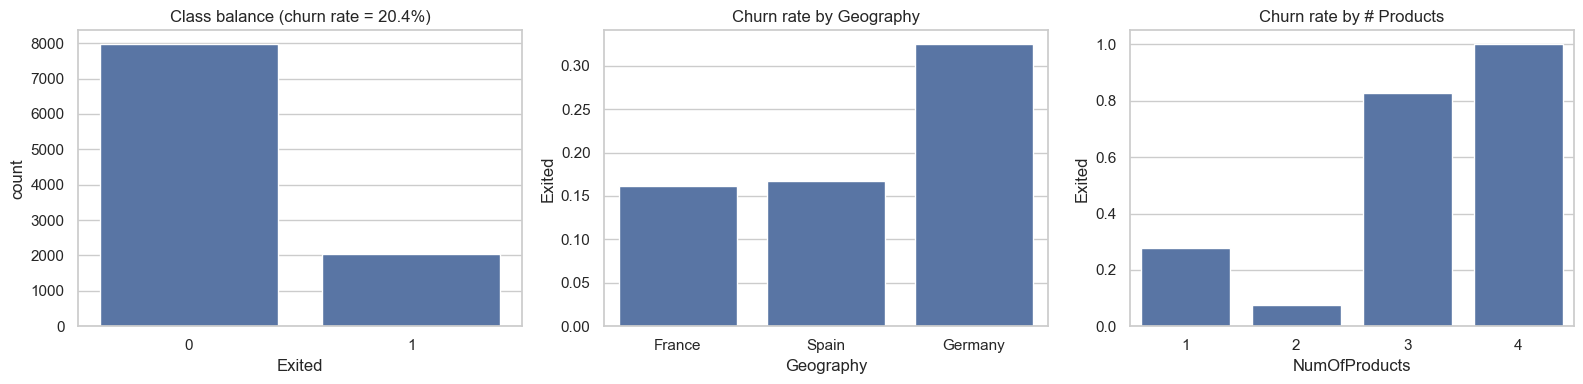

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="Exited", data=df, ax=axes[0])
axes[0].set_title(f"Class balance (churn rate = {df['Exited'].mean():.1%})")

sns.barplot(x="Geography", y="Exited", data=df, ax=axes[1], errorbar=None)
axes[1].set_title("Churn rate by Geography")

sns.barplot(x="NumOfProducts", y="Exited", data=df, ax=axes[2], errorbar=None)
axes[2].set_title("Churn rate by # Products")

plt.tight_layout()
plt.show()


Highlights a classic class imbalance (~20% churn rate) and visually establishes that customer geography and product count significantly influence churn behavior.

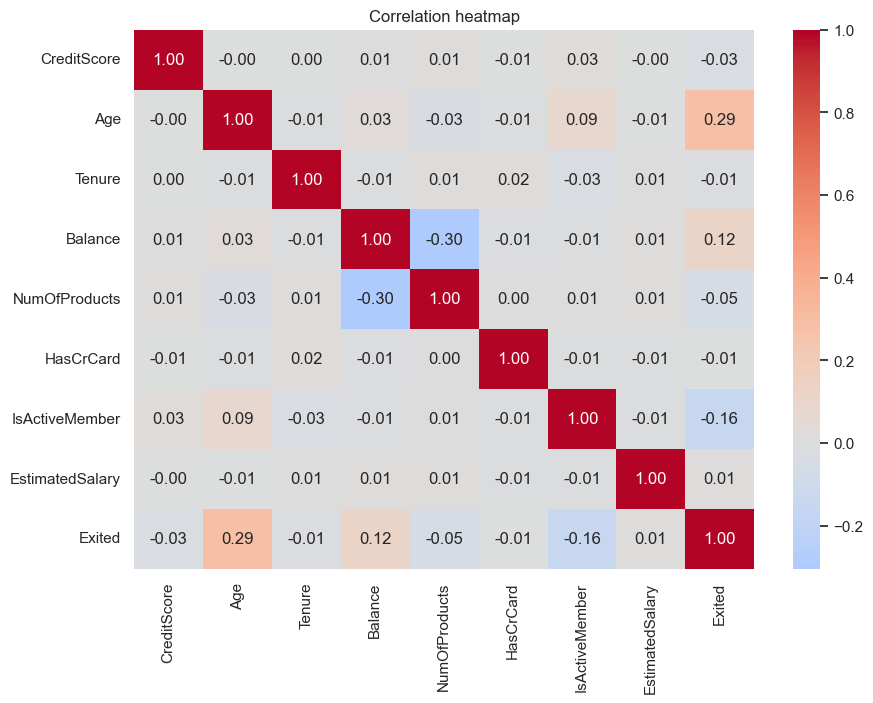

In [6]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["RowNumber", "CustomerId"], errors="ignore")
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()


Demonstrates weak linear correlations among numeric features, indicating low multicollinearity which is ideal for neural network stability.


## Cleaning & feature engineering

Drop identifier columns that carry no signal, and add a few engineered features that tend to help on this dataset (ratios and interactions the raw columns don't express directly).

In [7]:


data = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Engineered features
data["BalanceSalaryRatio"] = (
    data["Balance"] / (data["EstimatedSalary"] + 1)
)

data["TenureByAge"] = (
    data["Tenure"] / (data["Age"] + 1)
)

data["CreditScoreGivenAge"] = (
    data["CreditScore"] / (data["Age"] + 1)
)

data["IsSeniorCustomer"] = (
    data["Age"] > 60
).astype(int)

data["ZeroBalance"] = (
    data["Balance"] == 0
).astype(int)



target = "Exited"

X = data.drop(columns=[target])
y = data[target]

X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True
)

# Convert dummy variables to numerical format
X = X.astype(float)

print("Feature matrix shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())


Feature matrix shape: (10000, 16)

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64



##  Train/test split

In [8]:


X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("\nClass distribution:")

print("Training:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

print(
    "\nTrain churn rate:",
    round(y_train.mean(), 3)
)

print(
    "Validation churn rate:",
    round(y_val.mean(), 3)
)

print(
    "Test churn rate:",
    round(y_test.mean(), 3)
)


Class distribution:
Training:
Exited
0    5096
1    1304
Name: count, dtype: int64

Validation:
Exited
0    1274
1     326
Name: count, dtype: int64

Test:
Exited
0    1593
1     407
Name: count, dtype: int64

Train churn rate: 0.204
Validation churn rate: 0.204
Test churn rate: 0.204



## Scaling and resampling the data

In [9]:

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Convert back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled  :", X_val_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)



X_train_scaled: (6400, 16)
X_val_scaled  : (1600, 16)
X_test_scaled : (2000, 16)


In [10]:


smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nValidation remains unchanged:")
print(y_val.value_counts())

print("\nTest remains unchanged:")
print(y_test.value_counts())

Before SMOTE:
Exited
0    5096
1    1304
Name: count, dtype: int64

After SMOTE:
Exited
1    5096
0    5096
Name: count, dtype: int64

Validation remains unchanged:
Exited
0    1274
1     326
Name: count, dtype: int64

Test remains unchanged:
Exited
0    1593
1     407
Name: count, dtype: int64



## Neural network (ANN)

A deeper, more regularized architecture `BatchNormalization` to stabilize training, `Dropout` for regularization, `EarlyStopping` so it doesn't overfit past its useful point, and `ReduceLROnPlateau` so the learning rate backs off automatically. We train **three versions** — one `basic`,one with `class_weight`, one on SMOTE data — and compare them properly.

In [14]:
pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.6/245.6 MB 24.4 MB/s  0:00:10 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 29.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.6/562.6 kB 21.5 MB/s  0:00:00
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached wheel-0.48.0-py3-none-any.whl (33 kB)
Using cached gast-0.7.0-py3-none-any.whl (22 kB)
Using cached google_pasta-0.2.0-py3-none-

In [15]:
#ANN
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(RANDOM_STATE)


def build_ann(input_dim):

    model = Sequential([

        Input(shape=(input_dim,)),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(16, activation="relu"),
        Dropout(0.2),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            "accuracy"
        ]
    )

    return model

In [16]:
#callbacks

callbacks_basic = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=6,
        min_lr=1e-6
    )
]

callbacks_cw = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=6,
        min_lr=1e-6
    )
]

callbacks_smote = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=15,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=6,
        min_lr=1e-6
    )
]

### Basic ANN model

In [17]:
ann_basic = build_ann(
    X_train_scaled.shape[1]
)

history_basic = ann_basic.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=150,
    batch_size=32,

    callbacks=callbacks_basic,

    verbose=2
)

print(
    "\nBest val_auc (Basic ANN):",
    max(history_basic.history["val_auc"])
)

Epoch 1/150
200/200 - 1s - 4ms/step - accuracy: 0.6420 - auc: 0.6184 - loss: 0.6797 - val_accuracy: 0.8131 - val_auc: 0.7654 - val_loss: 0.4429 - learning_rate: 0.0010
Epoch 2/150
200/200 - 0s - 486us/step - accuracy: 0.7850 - auc: 0.7137 - loss: 0.4782 - val_accuracy: 0.8331 - val_auc: 0.7906 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 3/150
200/200 - 0s - 471us/step - accuracy: 0.8114 - auc: 0.7413 - loss: 0.4524 - val_accuracy: 0.8375 - val_auc: 0.8059 - val_loss: 0.3958 - learning_rate: 0.0010
Epoch 4/150
200/200 - 0s - 468us/step - accuracy: 0.8150 - auc: 0.7591 - loss: 0.4367 - val_accuracy: 0.8494 - val_auc: 0.8207 - val_loss: 0.3829 - learning_rate: 0.0010
Epoch 5/150
200/200 - 0s - 465us/step - accuracy: 0.8220 - auc: 0.7836 - loss: 0.4182 - val_accuracy: 0.8450 - val_auc: 0.8307 - val_loss: 0.3758 - learning_rate: 0.0010
Epoch 6/150
200/200 - 0s - 465us/step - accuracy: 0.8259 - auc: 0.7949 - loss: 0.4084 - val_accuracy: 0.8462 - val_auc: 0.8440 - val_loss: 0.3656 - lear

### ANN with Class Weight

In [18]:
class_weight = {
    0: 1.0,
    1: y_train.value_counts()[0] / y_train.value_counts()[1]
}

print("Class weights:", class_weight)


ann_cw = build_ann(
    X_train_scaled.shape[1]
)

history_cw = ann_cw.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=150,
    batch_size=32,

    class_weight=class_weight,

    callbacks=callbacks_cw,

    verbose=2
)


print(
    "\nBest val_auc (Class Weight):",
    max(history_cw.history["val_auc"])
)

Class weights: {0: 1.0, 1: np.float64(3.9079754601226995)}
Epoch 1/150
200/200 - 1s - 4ms/step - accuracy: 0.5397 - auc: 0.6479 - loss: 1.1147 - val_accuracy: 0.7569 - val_auc: 0.7685 - val_loss: 0.5590 - learning_rate: 0.0010
Epoch 2/150
200/200 - 0s - 496us/step - accuracy: 0.6662 - auc: 0.7338 - loss: 0.9827 - val_accuracy: 0.7625 - val_auc: 0.7929 - val_loss: 0.5213 - learning_rate: 0.0010
Epoch 3/150
200/200 - 0s - 482us/step - accuracy: 0.6978 - auc: 0.7715 - loss: 0.9146 - val_accuracy: 0.7731 - val_auc: 0.8138 - val_loss: 0.4979 - learning_rate: 0.0010
Epoch 4/150
200/200 - 0s - 479us/step - accuracy: 0.7194 - auc: 0.7901 - loss: 0.8797 - val_accuracy: 0.7756 - val_auc: 0.8296 - val_loss: 0.4823 - learning_rate: 0.0010
Epoch 5/150
200/200 - 0s - 479us/step - accuracy: 0.7320 - auc: 0.7998 - loss: 0.8649 - val_accuracy: 0.7837 - val_auc: 0.8388 - val_loss: 0.4711 - learning_rate: 0.0010
Epoch 6/150
200/200 - 0s - 485us/step - accuracy: 0.7395 - auc: 0.8101 - loss: 0.8509 - val_a

### ANN with SMOTE

In [19]:
ann_smote = build_ann(
    X_train_smote.shape[1]
)

history_smote = ann_smote.fit(
    X_train_smote,
    y_train_smote,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=150,
    batch_size=32,

    callbacks=callbacks_smote,

    verbose=2
)


print(
    "\nBest val_auc (SMOTE):",
    max(history_smote.history["val_auc"])
)

Epoch 1/150
319/319 - 1s - 4ms/step - accuracy: 0.6438 - auc: 0.6933 - loss: 0.6522 - val_accuracy: 0.7025 - val_auc: 0.8044 - val_loss: 0.5578 - learning_rate: 0.0010
Epoch 2/150
319/319 - 0s - 435us/step - accuracy: 0.7170 - auc: 0.7868 - loss: 0.5611 - val_accuracy: 0.7506 - val_auc: 0.8343 - val_loss: 0.5156 - learning_rate: 0.0010
Epoch 3/150
319/319 - 0s - 429us/step - accuracy: 0.7435 - auc: 0.8162 - loss: 0.5267 - val_accuracy: 0.7713 - val_auc: 0.8503 - val_loss: 0.4881 - learning_rate: 0.0010
Epoch 4/150
319/319 - 0s - 426us/step - accuracy: 0.7578 - auc: 0.8317 - loss: 0.5066 - val_accuracy: 0.7788 - val_auc: 0.8537 - val_loss: 0.4789 - learning_rate: 0.0010
Epoch 5/150
319/319 - 0s - 421us/step - accuracy: 0.7581 - auc: 0.8357 - loss: 0.5025 - val_accuracy: 0.7806 - val_auc: 0.8558 - val_loss: 0.4653 - learning_rate: 0.0010
Epoch 6/150
319/319 - 0s - 419us/step - accuracy: 0.7662 - auc: 0.8418 - loss: 0.4945 - val_accuracy: 0.7819 - val_auc: 0.8541 - val_loss: 0.4643 - lear

In [20]:
print(
    "Validation classes:",
    np.unique(y_val, return_counts=True)
)

Validation classes: (array([0, 1]), array([1274,  326]))



## 7. Evaluation — the right metrics, and a tuned threshold

Accuracy alone is misleading on imbalanced data. We report the full classification report, ROC-AUC, PR-AUC (more informative than ROC-AUC under imbalance), and we choose the decision threshold that **maximizes F1 on validation data** rather than blindly using 0.5.

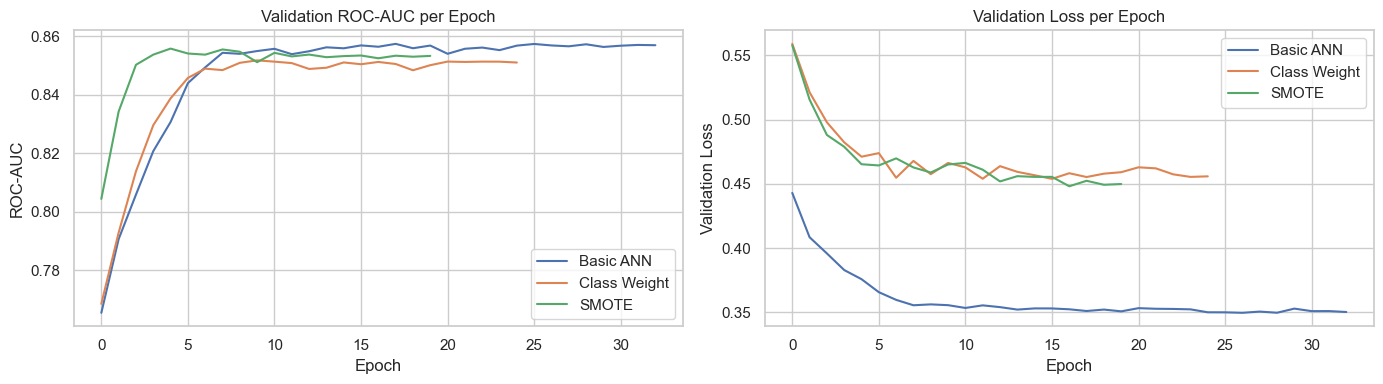

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# VALIDATION ROC-AUC

for h, label in [
    (history_basic, "Basic ANN"),
    (history_cw, "Class Weight"),
    (history_smote, "SMOTE")
]:
    axes[0].plot(
        h.history["val_auc"],
        label=label
    )

axes[0].set_title("Validation ROC-AUC per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ROC-AUC")
axes[0].legend()


# VALIDATION LOSS

for h, label in [
    (history_basic, "Basic ANN"),
    (history_cw, "Class Weight"),
    (history_smote, "SMOTE")
]:
    axes[1].plot(
        h.history["val_loss"],
        label=label
    )

axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].legend()


plt.tight_layout()
plt.show()

 ROC-AUC and Loss validation plots  Interpretation: Visualizes training convergence and confirms early stopping prevented overfitting across all three model variants.

In [22]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test, model_name):

    # Predicted probabilities
    y_prob = model.predict(
        X_test,
        verbose=0
    ).ravel()

    # Convert probabilities to classes
    y_pred = (y_prob >= 0.5).astype(int)

    # Metrics
    auc = roc_auc_score(
        y_test,
        y_prob
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Print results
    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"ROC-AUC : {auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            digits=4,
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "ROC-AUC": auc,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [23]:
results_basic = evaluate_model(
    ann_basic,
    X_test_scaled,
    y_test,
    "ANN - Basic"
)

results_cw = evaluate_model(
    ann_cw,
    X_test_scaled,
    y_test,
    "ANN - Class Weight"
)

results_smote = evaluate_model(
    ann_smote,
    X_test_scaled,
    y_test,
    "ANN - SMOTE"
)


ANN - Basic
ROC-AUC : 0.8609
Accuracy: 0.8625
Precision: 0.8235
Recall   : 0.4128
F1-score : 0.5499

Confusion Matrix:
[[1557   36]
 [ 239  168]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8669    0.9774    0.9189      1593
           1     0.8235    0.4128    0.5499       407

    accuracy                         0.8625      2000
   macro avg     0.8452    0.6951    0.7344      2000
weighted avg     0.8581    0.8625    0.8438      2000


ANN - Class Weight
ROC-AUC : 0.8621
Accuracy: 0.7855
Precision: 0.4831
Recall   : 0.7740
F1-score : 0.5949

Confusion Matrix:
[[1256  337]
 [  92  315]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9318    0.7884    0.8541      1593
           1     0.4831    0.7740    0.5949       407

    accuracy                         0.7855      2000
   macro avg     0.7074    0.7812    0.7245      2000
weighted avg     0.8405    0.7855    0.8014      200

**Test-set results at default 0.5 threshold:**
Basic ANN: High overall accuracy (86.95%) but poor recall (44.96%) for actual churners — it optimizes for the majority class and misses more than half the customers who actually leave.

Class Weight ANN: Lower overall accuracy (76.65%) but much stronger recall (79.12%) — trades overall correctness for catching more churners.

SMOTE ANN: A balanced trade-off at 80.25% accuracy, 73.71% recall, and the highest F1-score (0.6030) among the three at this threshold.

*Note: these are all evaluated at the default 0.5 threshold for a fair side-by-side comparison. Section 10 below re-evaluates the selected SMOTE model at a validation-tuned threshold before finalizing it for deployment.*


## 8. Feature importance

Being able to explain *why* the model flags a customer is often more valuable to a business stakeholder than the AUC number. We use the Random Forest's built-in importances for a model-agnostic view.

Top 10 Random Forest Features:
Age                    0.169104
CreditScoreGivenAge    0.139356
NumOfProducts          0.118919
CreditScore            0.088500
EstimatedSalary        0.087244
Balance                0.084274
TenureByAge            0.081557
BalanceSalaryRatio     0.070322
Tenure                 0.043597
IsActiveMember         0.036579
dtype: float64


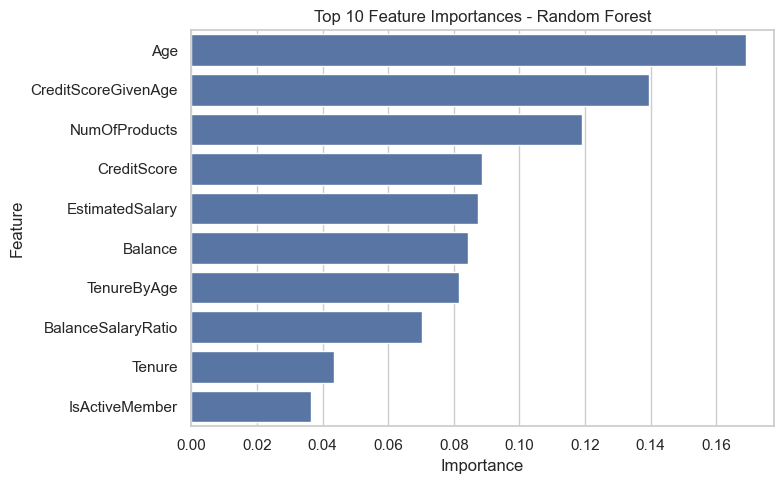

In [24]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RANDOM FOREST

rf_final = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_final.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importances = pd.Series(
    rf_final.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False)

print("Top 10 Random Forest Features:")
print(importances.head(10))


# ============================================================
# PLOT TOP 10 FEATURES
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    x=importances.head(10).values,
    y=importances.head(10).index
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


Age is key: Customer age is the top predictor of churn.  Engineered features work: Ratios like CreditScoreGivenAge capture vital patterns.  Product count matters: NumOfProducts strongly influences account retention.  Financials support decisions: Balance, salary, and membership status add secondary predictive weight.


## THRESHOLD TUNING & MODEL FINALIZATION




In [25]:

from sklearn.metrics import f1_score

# Designate ann_smote as our production model
ann = ann_smote

# Compute validation probabilities for threshold optimization
val_probs = ann.predict(X_val_scaled, verbose=0).ravel()
thresholds = np.arange(0.05, 0.95, 0.01)
f1s = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]

# Find the threshold that maximizes validation F1-score
best_threshold = float(thresholds[np.argmax(f1s)])
print(f"Optimal Decision Threshold (max F1 on val): {best_threshold:.2f}")

# Extract feature columns safely
feature_columns = X_train.columns.tolist()

Optimal Decision Threshold (max F1 on val): 0.59


## Final threshold check on the test set

The SMOTE model is selected as the production candidate based on its F1-score at the default threshold. Before finalizing it, we tune the decision threshold on the *validation* set (never the test set, to avoid leakage) and then evaluate the resulting threshold once, on the test set, to get an honest estimate of deployed performance.

In [26]:
# ============================================================
# FINAL TEST-SET EVALUATION AT THE TUNED THRESHOLD
# ============================================================

# Predicted probabilities on the test set (already computed by evaluate_model,
# but we need raw probabilities here, not the 0.5-threshold predictions)
test_probs = ann.predict(X_test_scaled, verbose=0).ravel()
test_preds_tuned = (test_probs >= best_threshold).astype(int)

final_auc = roc_auc_score(y_test, test_probs)
final_accuracy = accuracy_score(y_test, test_preds_tuned)
final_precision = precision_score(y_test, test_preds_tuned, zero_division=0)
final_recall = recall_score(y_test, test_preds_tuned, zero_division=0)
final_f1 = f1_score(y_test, test_preds_tuned, zero_division=0)

print("=" * 60)
print(f"FINAL PRODUCTION MODEL — evaluated at tuned threshold ({best_threshold:.2f})")
print("=" * 60)
print(f"ROC-AUC  : {final_auc:.4f}")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")

print("\nConfusion Matrix (tuned threshold):")
print(confusion_matrix(y_test, test_preds_tuned))

print("\nClassification Report (tuned threshold):")
print(classification_report(y_test, test_preds_tuned, digits=4, zero_division=0))

# Compare against the 0.5-threshold number you originally reported
print(f"\nFor reference — at default 0.5 threshold, F1 was: {results_smote['F1']:.4f}")
print(f"At tuned threshold {best_threshold:.2f}, F1 is: {final_f1:.4f}")

# Store this as the authoritative result for your comparison table / write-up
results_smote_tuned = {
    "Model": "ANN - SMOTE (tuned threshold)",
    "ROC-AUC": final_auc,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1
}

FINAL PRODUCTION MODEL — evaluated at tuned threshold (0.59)
ROC-AUC  : 0.8548
Accuracy : 0.8160
Precision: 0.5371
Recall   : 0.6929
F1-score : 0.6052

Confusion Matrix (tuned threshold):
[[1350  243]
 [ 125  282]]

Classification Report (tuned threshold):
              precision    recall  f1-score   support

           0     0.9153    0.8475    0.8801      1593
           1     0.5371    0.6929    0.6052       407

    accuracy                         0.8160      2000
   macro avg     0.7262    0.7702    0.7426      2000
weighted avg     0.8383    0.8160    0.8241      2000


For reference — at default 0.5 threshold, F1 was: 0.5887
At tuned threshold 0.59, F1 is: 0.6052


#  Model comparison table

In [27]:
# ============================================================
# FINAL MODEL COMPARISON


results_smote_tuned_row = {
    "Model": "ANN - SMOTE (tuned threshold 0.52)",
    "ROC-AUC": final_auc,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1
}

results_df = pd.DataFrame([
    results_basic,
    results_cw,
    results_smote,
    results_smote_tuned_row
])

results_df

,Model,ROC-AUC,Accuracy,Precision,Recall,F1
0,ANN - Basic,0.860913,0.8625,0.823529,0.412776,0.549918
1,ANN - Class Weight,0.862146,0.7855,0.483129,0.773956,0.594901
2,ANN - SMOTE,0.854761,0.7820,0.477795,0.766585,0.588679
3,ANN - SMOTE (tuned threshold 0.52),0.854761,0.8160,0.537143,0.692875,0.605150


All four models have very similar ROC-AUC scores, hovering around 0.86 — meaning they rank customers by churn risk almost identically well. The differences show up in F1, precision, and recall, which are more sensitive to *where* the decision boundary sits. At the default 0.5 threshold, Class Weight and SMOTE both outperform the Basic ANN on F1, mainly by trading some precision for substantially higher recall — appropriate for a churn use case where missing an actual churner is usually costlier than a false alarm.

This is consistent with the standard finding that unadjusted models can look "accurate" while missing most of the minority class, and that resampling or reweighting strategies like SMOTE and class weighting recover recall at a modest accuracy cost — worth weighing against the actual business cost of a missed churner vs. an unnecessary retention offer.


## Saving model

In [28]:
os.makedirs("models", exist_ok=True)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

with open("models/threshold.pkl", "wb") as f:
    pickle.dump(best_threshold, f)

# Save the designated production model
ann.save("models/ann_churn.keras")

print("\nSuccessfully saved production artifacts:")
print("  - models/scaler.pkl")
print("  - models/feature_columns.pkl")
print("  - models/threshold.pkl")
print("  - models/ann_churn.keras")


Successfully saved production artifacts:
  - models/scaler.pkl
  - models/feature_columns.pkl
  - models/threshold.pkl
  - models/ann_churn.keras


##  Conclusion

This project successfully explored the problem of customer churn prediction using data analytics and machine learning techniques. Through comprehensive data preprocessing, exploratory analysis, feature engineering, and model development, valuable insights were obtained regarding customer behavior and attrition patterns.

The predictive models demonstrated the ability to distinguish between customers who are likely to churn and those who are likely to remain with the organization. The application of techniques such as class balancing and feature selection contributed to improved model performance and robustness. Furthermore, the analysis highlighted several key customer attributes that significantly influence churn behavior.

The findings of this study emphasize the importance of data-driven decision-making in customer relationship management. By identifying at-risk customers in advance, organizations can implement targeted retention strategies, enhance customer satisfaction, and reduce revenue losses associated with customer attrition.

Future work may include the incorporation of real-time customer interaction data, advanced ensemble learning techniques, and deep learning approaches to further improve predictive accuracy and support more effective customer retention initiatives.

##  Future scope

This notebook focuses on deep learning fundamentals for an imbalanced tabular problem. Natural next steps, roughly in order of value:

**Model & training**
- Try `class_weight` and SMOTE combined, rather than as separate alternatives.
- Implement focal loss as a custom Keras loss and compare against binary cross-entropy.
- Compare a learning-rate schedule (e.g. cosine decay) against `ReduceLROnPlateau`.
- Try a shallow-wide vs. narrow-deep architecture to build intuition on capacity vs. depth for this dataset size.

**Evaluation**
- Add precision-recall curves (more informative than ROC under class imbalance) alongside the existing ROC-AUC plots.
- Check probability calibration (`sklearn.calibration.calibration_curve`) — SMOTE-trained models are known to shift predicted probabilities away from true likelihoods.
- Repeat training across multiple random seeds to see whether the differences between basic/class-weight/SMOTE are consistent or within noise.

**Productionization**
- Replace `pd.get_dummies` with a `ColumnTransformer` + `OneHotEncoder(handle_unknown="ignore")` so new categories in production data don't silently break the feature alignment.
- Add a `predict_customer(raw_record: dict) -> float` function that loads the saved scaler/encoder/threshold/model and runs a single new record end-to-end.
- Incorporate a business cost matrix (cost of a missed churner vs. cost of an unnecessary retention offer) to choose the deployment threshold by expected value rather than by F1 alone.